
## **사용자 행동 로그 데이터를 활용한 Funnel 분석(Funnel Analysis)**
___
<br>



### **- 프로젝트 개요**

본 프로젝트는 사용자 행동 로그 데이터를 활용하여 **Funnel(퍼널) 분석**을 수행한 프로젝트이다.

사용자의 상품 조회(View)부터 장바구니(Cart), 구매(Purchase)에 이르는 행동 흐름을 분석하여 **단계별 전환율과 이탈 구간**을 확인하고, 사용자 행동 패턴을 기반으로 서비스 개선 및 마케팅 전략 수립에 활용할 수 있는 인사이트를 도출하는 것을 목표로 한다.

### **- 프로젝트 구성**

- 데이터 전처리 및 결측치 처리
- DAU(Daily Active Users) 추이 분석
- 사용자 평균 사이트 체류 시간 분석
- Funnel 단계별 사용자 수 및 전환율 분석
- Funnel 단계별 사용자 이탈 구간 분석
- 비즈니스 인사이트 도출

### **- 데이터셋**

- 데이터명: User Behavior Log Dataset
- 데이터 출처: 가상의 쇼핑몰 사용자 행동 로그 데이터를 바탕으로 제작된 제작된 실습용 모의 데이터
- 데이터셋은 사용자의 상품 조회부터 구매까지의 행동 로그를 기록한 데이터로, 사용자 행동 흐름(Funnel)을 분석하기 위한 실습용 데이터이다. <br>

#### **- 데이터 설명**

| 구분 | 컬럼명 | 설명 |
|------|--------|------|
| 이벤트 정보 | event_time | 이벤트 발생 시각 |
| | event_type | 사용자 행동(View, Cart, Remove from Cart, Purchase) |
| 상품 정보 | product_id | 상품 번호 |
| | category_id | 카테고리 번호 |
| | category_code | 카테고리명 |
| | brand | 브랜드명 |
| | price | 상품 가격 |
| 사용자 정보 | user_id | 사용자 번호 |
| | user_session | 사용자 세션 |

### **1. Import Libraries**

In [1]:
# =====================================
# 라이브러리 불러오기
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go # Funnel 그래프

import warnings
warnings.filterwarnings(action="ignore")
plt.rc("font", family="NanumGothic")

### **2. Data Loading**

In [2]:
# =====================================
# 데이터 불러오기
# =====================================

user_df = pd.read_csv("data/User Behavior Dataset.csv")
user_df

,Unnamed: 0,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,0,2020-01-01 00:00:00 UTC,view,5809910,1602943681873052386,NaN,grattol,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a
1,1,2020-01-01 00:00:09 UTC,view,5812943,1487580012121948301,NaN,kinetics,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a
2,2,2020-01-01 00:00:19 UTC,view,5798924,1783999068867920626,NaN,zinger,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3
3,3,2020-01-01 00:00:24 UTC,view,5793052,1487580005754995573,NaN,NaN,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711
4,4,2020-01-01 00:00:25 UTC,view,5899926,2115334439910245200,NaN,NaN,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb
...,...,...,...,...,...,...,...,...,...,...
3851288,4264743,2020-01-31 23:59:44 UTC,view,5877031,1487580010100293687,NaN,milv,3.49,564814969,fc7063a6-b45e-4863-babb-da4934b83388
3851289,4264744,2020-01-31 23:59:47 UTC,view,5870076,1783999064136745198,NaN,grattol,5.71,583267679,2806ff10-08bc-4811-9ab7-af074fe22a88
3851290,4264745,2020-01-31 23:59:50 UTC,view,5813496,1487580005553668971,NaN,NaN,11.03,583267679,2806ff10-08bc-4811-9ab7-af074fe22a88
3851291,4264746,2020-01-31 23:59:52 UTC,view,5796984,1487580005671109489,NaN,masura,1.73,417102560,dcf90ff3-a246-4b00-b39a-83e6444a0769


In [3]:
# =====================================
# 데이터 확인
# =====================================

user_df = user_df.drop(columns="Unnamed: 0") # 중복되는 인덱스 열은 삭제
user_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-01-01 00:00:00 UTC,view,5809910,1602943681873052386,NaN,grattol,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a
1,2020-01-01 00:00:09 UTC,view,5812943,1487580012121948301,NaN,kinetics,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a
2,2020-01-01 00:00:19 UTC,view,5798924,1783999068867920626,NaN,zinger,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3
3,2020-01-01 00:00:24 UTC,view,5793052,1487580005754995573,NaN,NaN,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711
4,2020-01-01 00:00:25 UTC,view,5899926,2115334439910245200,NaN,NaN,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb


### **3. Preprocessing**

#### **3-1. missing values**

In [4]:
# 데이터 정보 확인
print(user_df.shape)
user_df.info()

(3851293, 9)
<class 'pandas.DataFrame'>
RangeIndex: 3851293 entries, 0 to 3851292
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 520.3 MB


In [5]:
# 결측값 확인
user_df.isna().sum() 

event_time             0
event_type             0
product_id             0
category_id            0
category_code    3781761
brand            1601839
price                  0
user_id                0
user_session           0
dtype: int64

> 3851293x9 데이터이며, category_code(카테고리명), brand(브랜드명) 컬럼에 결측값 존재 

In [6]:
# 결측값이 있는 데이터 확인
user_df[user_df.isna().any(axis=1)] 

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-01-01 00:00:00 UTC,view,5809910,1602943681873052386,NaN,grattol,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a
1,2020-01-01 00:00:09 UTC,view,5812943,1487580012121948301,NaN,kinetics,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a
2,2020-01-01 00:00:19 UTC,view,5798924,1783999068867920626,NaN,zinger,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3
3,2020-01-01 00:00:24 UTC,view,5793052,1487580005754995573,NaN,NaN,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711
4,2020-01-01 00:00:25 UTC,view,5899926,2115334439910245200,NaN,NaN,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb
...,...,...,...,...,...,...,...,...,...
3851288,2020-01-31 23:59:44 UTC,view,5877031,1487580010100293687,NaN,milv,3.49,564814969,fc7063a6-b45e-4863-babb-da4934b83388
3851289,2020-01-31 23:59:47 UTC,view,5870076,1783999064136745198,NaN,grattol,5.71,583267679,2806ff10-08bc-4811-9ab7-af074fe22a88
3851290,2020-01-31 23:59:50 UTC,view,5813496,1487580005553668971,NaN,NaN,11.03,583267679,2806ff10-08bc-4811-9ab7-af074fe22a88
3851291,2020-01-31 23:59:52 UTC,view,5796984,1487580005671109489,NaN,masura,1.73,417102560,dcf90ff3-a246-4b00-b39a-83e6444a0769


In [7]:
# 기술통계량 확인
user_df.describe(include="all")

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
count,3851293,3851293,3.851293e+06,3.851293e+06,69532,2249454,3.851293e+06,3.851293e+06,3851293
unique,1747061,4,NaN,NaN,12,256,NaN,NaN,911574
top,2020-01-09 09:06:06 UTC,view,NaN,NaN,appliances.environment.vacuum,runail,NaN,NaN,3cfdc45c-8985-4c1d-b1e4-baa16a641e64
freq,257,2035188,NaN,NaN,30942,325712,NaN,NaN,2458
mean,NaN,NaN,5.490914e+06,1.558402e+18,NaN,NaN,9.096292e+00,5.339718e+08,NaN
std,NaN,NaN,1.295646e+06,1.747523e+17,NaN,NaN,2.036641e+01,8.753487e+07,NaN
min,NaN,NaN,3.752000e+03,1.487580e+18,NaN,NaN,-7.937000e+01,4.654960e+05,NaN
25%,NaN,NaN,5.725887e+06,1.487580e+18,NaN,NaN,2.370000e+00,4.960524e+08,NaN
50%,NaN,NaN,5.811802e+06,1.487580e+18,NaN,NaN,4.220000e+00,5.674747e+08,NaN
75%,NaN,NaN,5.859462e+06,1.487580e+18,NaN,NaN,7.320000e+00,5.983570e+08,NaN


In [8]:
# 주요 str 타입의 데이터 값 확인
user_df["event_type"].unique()

<ArrowStringArray>
['view', 'cart', 'remove_from_cart', 'purchase']
Length: 4, dtype: str

> - **event_type**: 이벤트 종류
>   - view: 상품을 조회
>   - cart: 상품을 카트에 추가
>   - remove_from_cart: 상품을 카트에서 제거
>   - purchase: 구매

#### **3-2. feature engineering**
 - 데이터 타입 변경
 - 불필요한 컬럼 정리
 - 날짜 컬럼 추가

* 데이터 타입 변경

In [9]:
user_df.dtypes

event_time           str
event_type           str
product_id         int64
category_id        int64
category_code        str
brand                str
price            float64
user_id            int64
user_session         str
dtype: object

In [10]:
# 날짜형 데이터로 변환
user_df["event_time"] = pd.to_datetime(user_df["event_time"], format="%Y-%m-%d %H:%M:%S UTC")
print(user_df.dtypes)
user_df.head()

event_time       datetime64[us]
event_type                  str
product_id                int64
category_id               int64
category_code               str
brand                       str
price                   float64
user_id                   int64
user_session                str
dtype: object


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-01-01 00:00:00,view,5809910,1602943681873052386,NaN,grattol,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a
1,2020-01-01 00:00:09,view,5812943,1487580012121948301,NaN,kinetics,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a
2,2020-01-01 00:00:19,view,5798924,1783999068867920626,NaN,zinger,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3
3,2020-01-01 00:00:24,view,5793052,1487580005754995573,NaN,NaN,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711
4,2020-01-01 00:00:25,view,5899926,2115334439910245200,NaN,NaN,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb


* 불필요한 컬럼 정리: 결측값

In [11]:
# 결측값이 차지하는 비중
print(len(user_df[user_df["category_code"].isna()]) / len(user_df))
print(len(user_df[user_df["brand"].isna()]) / len(user_df))

0.9819458036560709
0.4159223928171656


In [12]:
#category_code, brand에 너무 많은 컬럼이 비어있고, 카테고리나 브랜드별로 분석할 계획이 없으므로 해당 컬럼들을 제거
user_df = user_df.drop(columns=["category_code", "brand"])
user_df.head()

,event_time,event_type,product_id,category_id,price,user_id,user_session
0,2020-01-01 00:00:00,view,5809910,1602943681873052386,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a
1,2020-01-01 00:00:09,view,5812943,1487580012121948301,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a
2,2020-01-01 00:00:19,view,5798924,1783999068867920626,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3
3,2020-01-01 00:00:24,view,5793052,1487580005754995573,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711
4,2020-01-01 00:00:25,view,5899926,2115334439910245200,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb


* 날짜 컬럼 추가

In [13]:
date_ymd = user_df["event_time"].dt.date
idx_event_time = user_df.columns.get_loc("event_time")
user_df.insert( # 컬럼 추가
    loc=idx_event_time+1, # 인덱스+1 위치에 추가
    column="date_ymd", # 추가할 컬럼명
    value=date_ymd
)
user_df.head()

,event_time,date_ymd,event_type,product_id,category_id,price,user_id,user_session
0,2020-01-01 00:00:00,2020-01-01,view,5809910,1602943681873052386,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a
1,2020-01-01 00:00:09,2020-01-01,view,5812943,1487580012121948301,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a
2,2020-01-01 00:00:19,2020-01-01,view,5798924,1783999068867920626,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3
3,2020-01-01 00:00:24,2020-01-01,view,5793052,1487580005754995573,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711
4,2020-01-01 00:00:25,2020-01-01,view,5899926,2115334439910245200,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb


In [14]:
user_df.dtypes

event_time      datetime64[us]
date_ymd                object
event_type                 str
product_id               int64
category_id              int64
price                  float64
user_id                  int64
user_session               str
dtype: object

In [15]:
# 날짜형 데이터로 변환
user_df["date_ymd"] = pd.to_datetime(user_df["date_ymd"], format="%Y-%m-%d")
user_df.dtypes

event_time      datetime64[us]
date_ymd         datetime64[s]
event_type                 str
product_id               int64
category_id              int64
price                  float64
user_id                  int64
user_session               str
dtype: object

In [16]:
# 2020.01 한 달간의 데이터
print(user_df["date_ymd"].min(), " ~ ", user_df["date_ymd"].max())

2020-01-01 00:00:00  ~  2020-01-31 00:00:00


### **4. Analysis**

- DAU(일간 활성 사용자수) 추이
- 사이트 체류시간 평균
- 퍼널 분석

#### **4-1. DAU(일간 활성 사용자수) 추이 확인**
 - 어느 일자, 요일에 가장 많이 방문하는가?

In [17]:
# 일별 중복 제거 방문자 수
dau = user_df.groupby("date_ymd")["user_id"].nunique().reset_index()
dau = dau.rename(columns={"user_id": "dau"})
dau

,date_ymd,dau
0,2020-01-01,11765
1,2020-01-02,14039
2,2020-01-03,15396
3,2020-01-04,16044
4,2020-01-05,16511
5,2020-01-06,15707
6,2020-01-07,17099
7,2020-01-08,18580
8,2020-01-09,19879
9,2020-01-10,18878


In [18]:
# 가장 많이 방문한 날
dau.sort_values(by="dau", ascending=False).head()

,date_ymd,dau
13,2020-01-14,22417
14,2020-01-15,22131
12,2020-01-13,21252
26,2020-01-27,20821
28,2020-01-29,20813


In [19]:
# 가장 적게 방문한 날
dau.sort_values(by="dau", ascending=True).head()

,date_ymd,dau
0,2020-01-01,11765
1,2020-01-02,14039
2,2020-01-03,15396
5,2020-01-06,15707
17,2020-01-18,15897


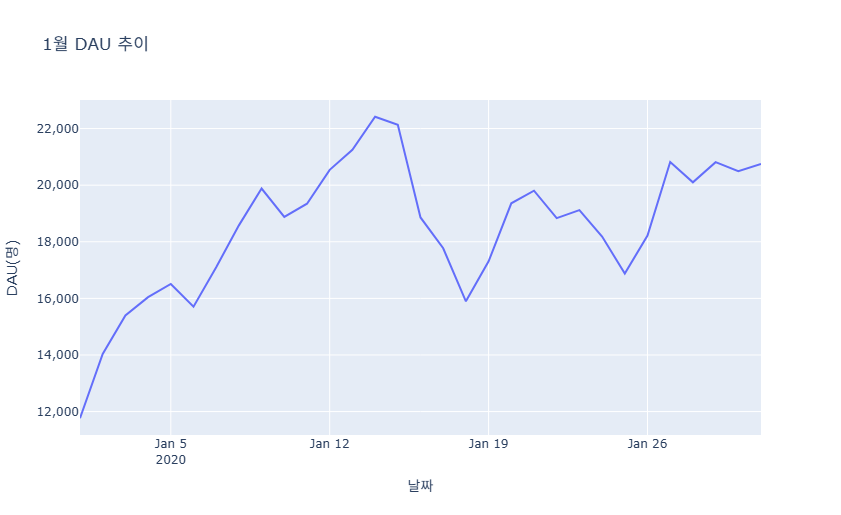

In [20]:
# 1월 DAU 추이 시각화
fig = go.Figure(
    go.Scatter(x=dau["date_ymd"], y=dau["dau"]))

fig.update_layout(
    title="1월 DAU 추이",
    xaxis_title="날짜",
    yaxis_title="DAU(명)",
    width=900, 
    height=500,
    yaxis=dict(tickformat=",")
)

fig.show()

> 월초에는 전반적으로 DAU가 낮게 나타났으며, 18일과 25일 등 특정 날짜에서 반복적으로 감소하는 경향을 보임

* 요일별 주기성 확인

In [21]:
# 요일 컬럼 추가
dau["day_of_week1"] = dau["date_ymd"].dt.day_name()
dau["day_of_week2"] = dau["date_ymd"].dt.day_of_week
dau

,date_ymd,dau,day_of_week1,day_of_week2
0,2020-01-01,11765,Wednesday,2
1,2020-01-02,14039,Thursday,3
2,2020-01-03,15396,Friday,4
3,2020-01-04,16044,Saturday,5
4,2020-01-05,16511,Sunday,6
5,2020-01-06,15707,Monday,0
6,2020-01-07,17099,Tuesday,1
7,2020-01-08,18580,Wednesday,2
8,2020-01-09,19879,Thursday,3
9,2020-01-10,18878,Friday,4


In [22]:
# 요일별 DAU 평균
avg_dau_by_dow = dau.groupby(["day_of_week1", "day_of_week2"])[["dau"]].mean().reset_index()
avg_dau_by_dow = avg_dau_by_dow.sort_values("day_of_week1")
avg_dau_by_dow

,day_of_week1,day_of_week2,dau
0,Friday,4,18195.80
1,Monday,0,19284.75
2,Saturday,5,17041.00
3,Sunday,6,18146.25
4,Thursday,3,18477.80
5,Tuesday,1,19855.50
6,Wednesday,2,18425.20


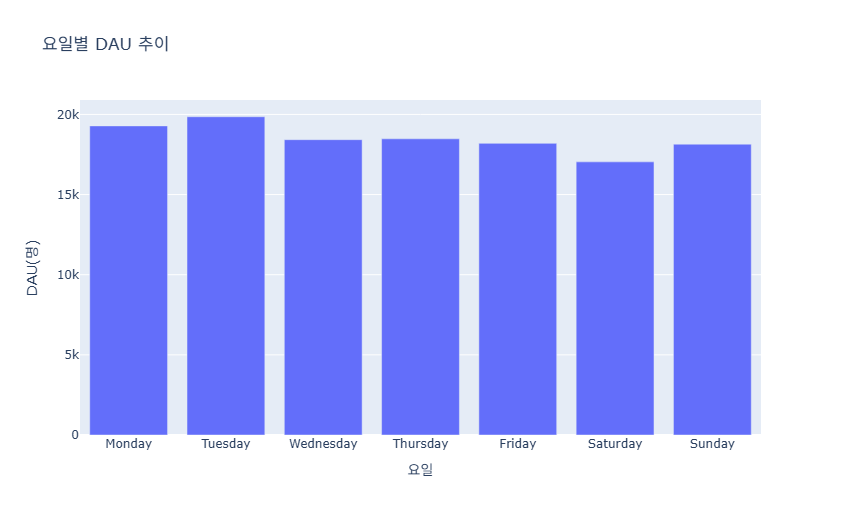

In [23]:
# 1월 DAU 추이 시각화
avg_dau_by_dow = avg_dau_by_dow.sort_values("day_of_week2") # 순서 정렬
fig = go.Figure(
    go.Bar(x=avg_dau_by_dow["day_of_week1"],
           y=avg_dau_by_dow["dau"]
    )
)

fig.update_layout(
    title="요일별 DAU 추이",
    xaxis_title="요일",
    yaxis_title="DAU(명)",
    width=900, 
    height=500
)
fig.show()

> 화요일의 평균 DAU가 가장 높았으며, 주말로 갈수록 감소하는 경향을 보임

#### **4-2. 사이트 체류시간 평균 확인**
 - 체류시간: 한 세션의 끝에서 시작시간을 뺀 값으로 정의
 - 조회만 한 유저, 카트에 담은 유저, 구매까지 한 유저별로 체류시간이 어떻게 다른가?

In [24]:
# 중복 세션 확인  ex) 3cfdc45c-8985-4c1d-b1e4-baa16a641e64
user_df["user_session"].value_counts().head()

user_session
3cfdc45c-8985-4c1d-b1e4-baa16a641e64    2458
12fb1cda-1c2f-4928-bea6-d70ac416c940    1774
15843513-b7d9-4fa4-8aed-42f39bb99767    1704
a062f07b-4eef-4266-8660-b3040ed412aa    1400
a69b0997-93a9-44e5-9c74-1c36ddacd643    1293
Name: count, dtype: int64

In [25]:
# 한 세션 안에서 여러 이벤트 발생
user_df[user_df["user_session"] == "3cfdc45c-8985-4c1d-b1e4-baa16a641e64"].sort_values("event_time")

,event_time,date_ymd,event_type,product_id,category_id,price,user_id,user_session
219511,2020-01-03 15:15:10,2020-01-03,remove_from_cart,5885588,1487580006350586771,79.21,568233448,3cfdc45c-8985-4c1d-b1e4-baa16a641e64
219514,2020-01-03 15:15:12,2020-01-03,remove_from_cart,5885588,1487580006350586771,79.21,568233448,3cfdc45c-8985-4c1d-b1e4-baa16a641e64
219516,2020-01-03 15:15:13,2020-01-03,remove_from_cart,5697545,1487580013950664926,107.94,568233448,3cfdc45c-8985-4c1d-b1e4-baa16a641e64
219517,2020-01-03 15:15:13,2020-01-03,remove_from_cart,5907080,1487580006350586771,79.21,568233448,3cfdc45c-8985-4c1d-b1e4-baa16a641e64
219519,2020-01-03 15:15:14,2020-01-03,remove_from_cart,5907080,1487580006350586771,79.21,568233448,3cfdc45c-8985-4c1d-b1e4-baa16a641e64
...,...,...,...,...,...,...,...,...
235824,2020-01-03 17:19:15,2020-01-03,cart,5911002,1487580007675986893,1.43,568233448,3cfdc45c-8985-4c1d-b1e4-baa16a641e64
235828,2020-01-03 17:19:16,2020-01-03,cart,5910998,1487580007575323592,1.43,568233448,3cfdc45c-8985-4c1d-b1e4-baa16a641e64
235845,2020-01-03 17:19:23,2020-01-03,cart,5910977,1487580005134238553,3.17,568233448,3cfdc45c-8985-4c1d-b1e4-baa16a641e64
235856,2020-01-03 17:19:30,2020-01-03,cart,5910976,1487580005134238553,3.17,568233448,3cfdc45c-8985-4c1d-b1e4-baa16a641e64


> 2020-01-03 15:15:10 ~ 2020-01-03 17:19:37 까지가 한 세션

In [26]:
# 체류시간(dutation) 계산
duration = user_df.groupby("user_session")["event_time"].agg(["max", "min"]).reset_index()
duration["duration"] = duration["max"] - duration["min"]
duration

,user_session,max,min,duration
0,0000061d-f3e9-484b-8c73-e54f355032a3,2020-01-16 03:30:41,2020-01-16 03:30:41,0 days 00:00:00
1,00000ac8-0015-4f12-996a-be2896323738,2020-01-24 22:22:20,2020-01-24 22:22:20,0 days 00:00:00
2,00001ca1-f2df-4572-b0b8-e752e2064aae,2020-01-01 19:09:23,2020-01-01 19:09:23,0 days 00:00:00
3,00002db7-16b6-4db2-bf8b-7a1cb6bd0e7f,2020-01-22 16:51:50,2020-01-22 16:51:50,0 days 00:00:00
4,00002f68-09b8-4db3-a092-aeff45fd13ad,2020-01-25 07:17:58,2020-01-25 07:17:58,0 days 00:00:00
...,...,...,...,...
911569,ffff7b96-9751-4eaa-806e-fe979cc00dc8,2020-01-25 11:32:02,2020-01-24 16:57:30,0 days 18:34:32
911570,ffff80e2-ad33-4704-9ffe-d6c612e9641f,2020-01-21 18:07:47,2020-01-21 18:07:47,0 days 00:00:00
911571,ffff8da3-b79a-48f2-888c-117f2d1a7793,2020-01-26 10:53:09,2020-01-26 10:53:09,0 days 00:00:00
911572,ffff9422-39ba-4cdf-afd1-a9d87bb3d79b,2020-01-13 09:55:09,2020-01-13 09:55:09,0 days 00:00:00


* 체류시간의 평균

In [27]:
print(duration["duration"].mean()) # 평균 약 1시간동안 머무름

0 days 00:59:16.683693


* 유저 행동별(event_type) 체류시간 비교: **조회**만 한 유저, **카트**에 담은 유저, **구매**까지 한 유저별로 체류시간이 어떻게 다른가?

In [28]:
# 피벗테이블을 활용해 각 유저 세션의 행동별로 횟수 컬럼 생성
session_pivot = pd.pivot_table(data=user_df,
                               values="event_time", # 집계할 값 
                               index="user_session", # 행 기준 그룹화할 열
                               columns="event_type", # 열 기준 그룹화할 열
                               aggfunc="count").reset_index().fillna(0)
session_pivot

event_type,user_session,cart,purchase,remove_from_cart,view
0,0000061d-f3e9-484b-8c73-e54f355032a3,0.0,0.0,0.0,1.0
1,00000ac8-0015-4f12-996a-be2896323738,0.0,0.0,0.0,1.0
2,00001ca1-f2df-4572-b0b8-e752e2064aae,0.0,0.0,0.0,1.0
3,00002db7-16b6-4db2-bf8b-7a1cb6bd0e7f,0.0,0.0,0.0,1.0
4,00002f68-09b8-4db3-a092-aeff45fd13ad,0.0,0.0,0.0,1.0
...,...,...,...,...,...
911569,ffff7b96-9751-4eaa-806e-fe979cc00dc8,1.0,0.0,2.0,10.0
911570,ffff80e2-ad33-4704-9ffe-d6c612e9641f,0.0,0.0,0.0,1.0
911571,ffff8da3-b79a-48f2-888c-117f2d1a7793,0.0,0.0,0.0,1.0
911572,ffff9422-39ba-4cdf-afd1-a9d87bb3d79b,0.0,0.0,0.0,1.0


In [29]:
# 카트 담기, 구매 행동을 한 세션들을 분류
cart_session = list(session_pivot[session_pivot["cart"] > 0]["user_session"])
purchase_session = list(session_pivot[session_pivot["purchase"] > 0]["user_session"])

cart_session[:5], purchase_session[:5]

(['0000b977-340c-45e1-9588-2bb26fda52eb',
  '00025691-523f-43b2-897d-e01420c36f4f',
  '00034f2c-f94b-416f-9d87-08cc02034112',
  '00035747-f915-42f1-8cef-e480ff0ce583',
  '00040372-9fc7-4759-b96e-050e7a8f5c99'],
 ['0013b593-e8eb-4bcf-b117-441db7cd9c6d',
  '001955e7-9f9f-4aad-a585-0dc5b988fe2e',
  '001a3579-4bf6-45d7-b48d-1fbb7ecd40da',
  '001cfc10-201f-86fd-73b5-2f8fcfcf541d',
  '001f6463-08b9-4363-a079-21499489a1c1'])

In [30]:
# 조회: 카트 담기와 구매 행동 둘 다 하지 않은 경우의 체류시간
view = duration.loc[~duration["user_session"].isin(cart_session) & ~duration["user_session"].isin(purchase_session)]
view

,user_session,max,min,duration
0,0000061d-f3e9-484b-8c73-e54f355032a3,2020-01-16 03:30:41,2020-01-16 03:30:41,0 days 00:00:00
1,00000ac8-0015-4f12-996a-be2896323738,2020-01-24 22:22:20,2020-01-24 22:22:20,0 days 00:00:00
2,00001ca1-f2df-4572-b0b8-e752e2064aae,2020-01-01 19:09:23,2020-01-01 19:09:23,0 days 00:00:00
3,00002db7-16b6-4db2-bf8b-7a1cb6bd0e7f,2020-01-22 16:51:50,2020-01-22 16:51:50,0 days 00:00:00
4,00002f68-09b8-4db3-a092-aeff45fd13ad,2020-01-25 07:17:58,2020-01-25 07:17:58,0 days 00:00:00
...,...,...,...,...
911568,ffff25b6-656f-4833-a6fe-8f0f2e5975f7,2020-01-15 05:46:45,2020-01-15 05:46:45,0 days 00:00:00
911570,ffff80e2-ad33-4704-9ffe-d6c612e9641f,2020-01-21 18:07:47,2020-01-21 18:07:47,0 days 00:00:00
911571,ffff8da3-b79a-48f2-888c-117f2d1a7793,2020-01-26 10:53:09,2020-01-26 10:53:09,0 days 00:00:00
911572,ffff9422-39ba-4cdf-afd1-a9d87bb3d79b,2020-01-13 09:55:09,2020-01-13 09:55:09,0 days 00:00:00


In [31]:
# 카트 담기, 구매 행동을 한 경우의 체류시간
cart = duration.loc[duration["user_session"].isin(cart_session)]
purchase = duration.loc[duration["user_session"].isin(purchase_session)]

In [32]:
view_session_avg_duration = view["duration"].mean()
cart_session_avg_duration = cart["duration"].mean()
purchase_session_avg_duration = purchase["duration"].mean()

print(f"조회만 한 유저의 평균 체류시간: {view_session_avg_duration}")
print(f"카트에 담은 유저의 평균 체류시간: {cart_session_avg_duration}")
print(f"구매까지 한 유저의 평균 체류시간: {purchase_session_avg_duration}")

조회만 한 유저의 평균 체류시간: 0 days 00:38:30.953374
카트에 담은 유저의 평균 체류시간: 0 days 02:39:48.642760
구매까지 한 유저의 평균 체류시간: 0 days 06:42:21.679333


> 조회만 한 세션의 평균 체류시간은 약 39분, 카트에 상품을 담은 세션은 약 2시간 40분, 구매까지 완료한 세션은 약 6시간 42분으로 나타났으며, <br>
  이는 **구매 단계로 이어질수록 사용자의 평균 체류시간이 증가**하는 경향을 보여줌

#### **4-3. 퍼널 분석**
 - 어느 단계에서 유저들이 가장 많이 이탈하는가?

In [33]:
session_pivot[["view", "cart", "remove_from_cart", "purchase"]].sum()

event_type
view                2035188.0
cart                 957169.0
remove_from_cart     674317.0
purchase             184619.0
dtype: float64

* 각 단계별로 이탈된 로그 수 확인

In [34]:
# event_type(행동)별로 쌓여있는 로그의 수(발생한 횟수)
funnel = session_pivot[["view", "cart", "purchase"]].sum().to_frame().reset_index().rename(columns={0: "count"})
funnel

,event_type,count
0,view,2035188.0
1,cart,957169.0
2,purchase,184619.0


In [35]:
# 각 단계별 전환율
view_to_cart_rate = list(funnel["count"])[1] / list(funnel["count"])[0]
view_to_purchase_rate = list(funnel["count"])[2] / list(funnel["count"])[0]
funnel["retain_rate"] = [1, view_to_cart_rate, view_to_purchase_rate]
funnel

,event_type,count,retain_rate
0,view,2035188.0,1.000000
1,cart,957169.0,0.470310
2,purchase,184619.0,0.090713


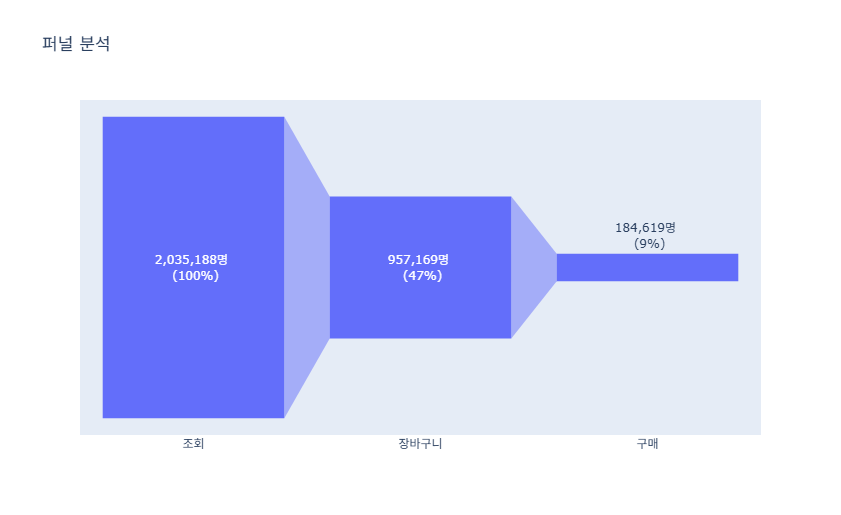

In [36]:
# 각 단계별 퍼널 차트 시각화
event_dict = {"view": "조회", "cart": "장바구니", "purchase": "구매"} # 각 단계별 라벨링

fig = go.Figure(
    go.Funnel(
        x=funnel["event_type"].map(event_dict),
        y=funnel["count"],
        orientation="v", 
        texttemplate="%{value:,.0f}명 <br> (%{percentInitial})" # 수치와 비중을 함께 출력
    )
)

fig.update_layout(
    title="퍼널 분석",
    width=900,
    height=500
)
fig.show()

> - 총 2,035,188건의 조회(View) 중 957,169건(**47.0%**)이 장바구니(Cart)로 이어졌으며, **53.0%** 는 조회 단계에서 이탈함
>
> - 장바구니에 담긴 957,169건 중 실제 184,619건(**19.3%**) 만 구매(Purchase)로 이어졌고, **80.7%** 는 구매 단계로 전환되지 않았음
>
> - 최종적으로 **조회 대비 구매 전환율은 9.1%** 로 나타났으며, **가장 큰 이탈은 장바구니 → 구매 단계(80.7%)** 에서 발생함

### **5. Funnel Analysis Insights**

* 가장 큰 이탈은 장바구니 → 구매 단계에서 발생하였다. (80.7%) <br>
* 조회 단계에서도 절반 이상이 이탈하지만, 구매 직전 단계의 전환율이 특히 낮아 결제 과정이나 구매 의사 결정 단계에 개선 여지가 있는 것으로 보인다.
* 따라서 구매 전환율을 높이기 위해서는 장바구니 이후 구매를 유도하는 전략(결제 프로세스 개선, 혜택 안내, 장바구니 리마인드 등)을 고려해볼 수 있다.